In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import re
import math
from IPython.display import display, HTML
import html

In [8]:
ROOT_DIR = r"D:\implementation\p2psta\implementation\results"  
RUN_NAME = "baseline128"  # 例如 "run_20250917_134512"; 设为 None 则按修改时间自动选最新的 run_*

def pick_run(root_dir: str, run_name: str | None = None) -> Path | None:
    root = Path(root_dir)
    if run_name:
        rd = root / run_name
        return rd if rd.exists() else None
    runs = sorted(
        [p for p in root.glob("run_*") if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )
    return runs[0] if runs else None

RUN_DIR = pick_run(ROOT_DIR, RUN_NAME)
print("Using RUN_DIR:", RUN_DIR)
if RUN_DIR is None:
    raise FileNotFoundError("No run_* folder found. ")

Using RUN_DIR: D:\implementation\p2psta\implementation\results\baseline128


### Parameters and Timings Explanation

- **[Global Config]**
  - `data.csv_path`: Path to the dataset file used for ingestion.
  - `data.max_ingest`: Maximum number of records to ingest (`None` means all records).

- **[SFC Config]**
  - `algorithm`: Space-filling curve used (`z3` = 3D Z-order).
  - `center_lat`: Reference latitude for distance-to-meter conversion.
  - `x_precision_m`, `y_precision_m`: Spatial resolution in meters for X (longitude) and Y (latitude).
  - `t_precision_s`: Temporal resolution in seconds.
  - `derived_bits`: Bit lengths (`lx`, `ly`, `lt`) used for encoding; `ring_m` is the total key length for the DHT ring.
  - `global_lat`, `global_lon`, `global_time`: Bounding box of the dataset in latitude, longitude, and time.

- **[Experiment Config]**
  - `stop_tail_bits`: Controls granularity of range decomposition; smaller values = finer ranges.
  - `merge_gap_keys`: Threshold for merging small gaps between ranges (to reduce fragmentation).
  - `max_ranges`: Maximum number of ranges allowed per query (`None` = unlimited).

- **[Metrics]**
  - `precise_hits`: Whether precise post-filtering of results is enabled.
  - `save_with_nodes`: Whether query results are saved with node-level details.

- **[Queries]**
  - Total number of queries run in the experiment.
  - Each query includes: name, spatial bounding box (`lat`, `lon`), and temporal window (`time`).

- **Timings**
  - `ingest_ms`: Time spent ingesting all data (milliseconds).
  - `query[<name>]_ms`: Execution time of each query in milliseconds.


In [9]:
params_path = Path(RUN_DIR) / "params.txt"
with open(params_path, "r", encoding="utf-8") as f:
    params_text = f.read()
print(params_text)


[Global Config]
data.csv_path=geolife_clean.csv
data.max_ingest=None

[SFC Config]
algorithm=z3
center_lat=39.9
time_bucket_s=None
max_ranges=None
max_depth=Some(24)
max_nodes=Some(50000)
tail_bits_guard=None

[Network Config]
num_nodes=128

[Placement Config]
mode=baseline
vnodes_per_node=10
smart.low_ratio=Some(0.99)
smart.high_ratio=Some(1.05)
derived_bits: lx=10 ly=10 lt=10 ring_m=30
global_lat=[39, 41] global_lon=[115, 118] global_time=[1176268800, 1343433600]

[Experiment Config]
stop_tail_bits=6
print_first=Some(15)
debug=Some(false)
prefix_bits=None

[Metrics]
precise_hits=Some(true)
save_with_nodes=Some(true)

[Queries] total=3
Q00: name=Some("forbidden_city"), lat=[39.906,39.923], lon=[116.386,116.411], time=[2008-08-01T03:00:00Z,2008-08-10T03:15:00Z]
Q01: name=Some("Guomao_CBD"), lat=[39.906,39.923], lon=[116.44,116.48], time=[2008-08-01T03:00:00Z,2008-08-10T03:15:00Z]
Q02: name=Some("Changping_District"), lat=[40.08,40.15], lon=[116.22,116.3], time=[2008-08-01T03:00:00Z,200

In [10]:
timings_path = Path(RUN_DIR) / "timings.txt"
with open(timings_path, "r", encoding="utf-8") as f:
    timings_text = f.read()
print(timings_text)

ingest_ms=19553
query[forbidden_city]_ms=128
query[Guomao_CBD]_ms=94
query[Changping_District]_ms=29



### About node_distribution.csv
This file summarizes how data is distributed across nodes in the DHT ring.

- **pnode_idx**: Index of the node in the experiment (0-based).  
- **node_id**: Identifier of the node on the DHT ring.  
- **total_count**: Number of records stored on this node.  
- **min_key**: Smallest key value stored on this node.  
- **max_key**: Largest key value stored on this node.  
- **key_span** (derived): The difference between `max_key` and `min_key`, indicating the portion of key space covered by the node.

In [11]:
csv_path = Path(RUN_DIR) / "node_distribution.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"node_distribution.csv not found at: {csv_path}")

# 读取 CSV；把空白当作缺失值处理
df = pd.read_csv(
    csv_path,
    dtype={"pnode_idx": "Int64", "node_id": "Int64", "total_count": "Int64"},
    na_values=["", " ", "NA", "NaN"]
)

# 确保 min_key / max_key 为可空整型；缺失保持 NaN
for col in ["min_key", "max_key"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# 计算 key_span（max_key - min_key）；缺失用 0
df["key_span"] = (df["max_key"] - df["min_key"]).astype("Int64")
df["key_span"] = df["key_span"].fillna(0)


df.head() 




,pnode_idx,node_id,total_count,min_key,max_key,key_span
0,0,0,0,<NA>,<NA>,0
1,1,8388608,991,4941312,8205504,3264192
2,2,16777216,0,<NA>,<NA>,0
3,3,25165824,3846,21504512,24885120,3380608
4,4,33554432,0,<NA>,<NA>,0


### Figure 1: Records per node
This chart shows the total number of records (`total_count`) stored on each node.  
- **X-axis:** Node index (`pnode_idx`)  
- **Y-axis:** Number of records stored  
The purpose of this figure is to reveal how evenly the data records are distributed across nodes. A balanced distribution indicates good load balancing, while large differences suggest potential hotspots.


In [12]:
summary_stats = {
    "total_count": {
        "mean": df["total_count"].mean(),
        "sum": df["total_count"].sum(),
        "std": df["total_count"].std(),
        'min': df['total_count'].min(),
        'max': df['total_count'].max(),
    },
    "key_span": {
        "mean": df["key_span"].mean(),
        "sum": df["key_span"].sum(),
        "std": df["key_span"].std(),
        'min': df['key_span'].min(),
        'max': df['key_span'].max(),
    }
}
summary_stats_df = pd.DataFrame(summary_stats)
display(HTML(summary_stats_df.to_html(float_format=lambda x: f"{x:,.4f}")))

,total_count,key_span
mean,"153,376.8438","3,783,094.0000"
sum,"19,632,236.0000","484,236,032.0000"
std,"945,544.9554","3,319,414.7126"
min,0.0000,0.0000
max,"10,120,196.0000","8,374,528.0000"


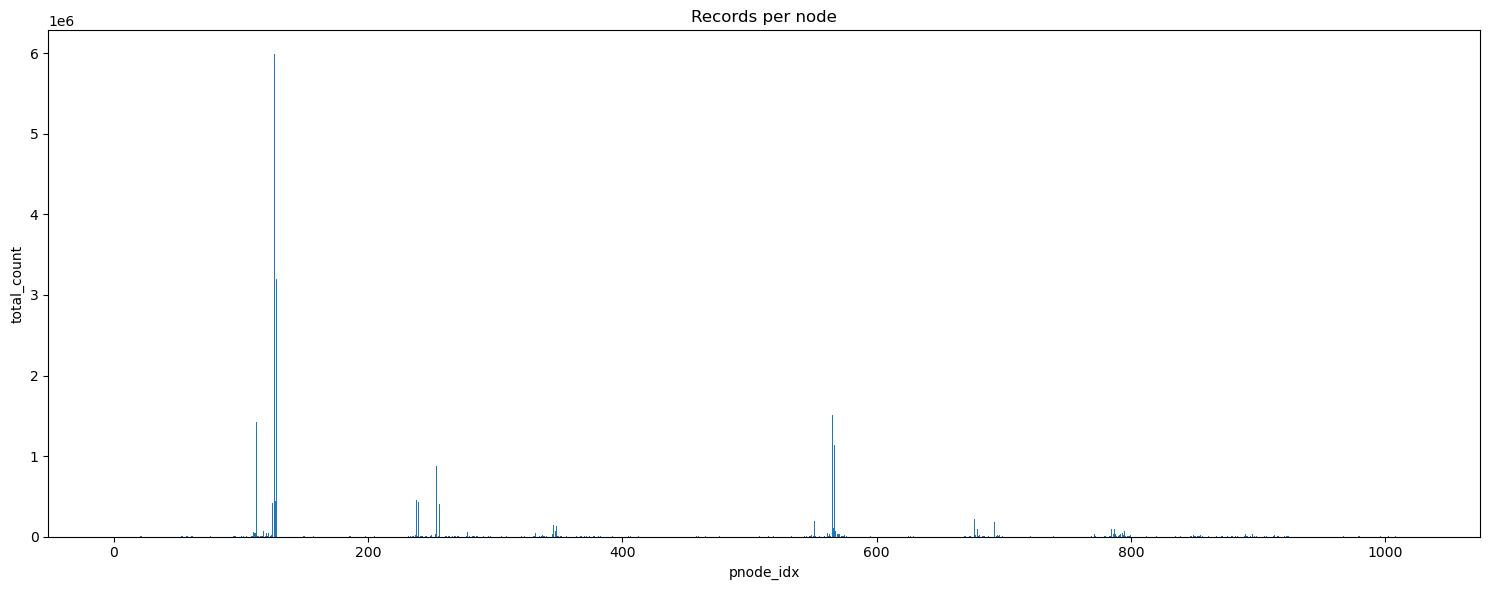

In [11]:
# --- 图1：每个 node 的 total_count ---
plt.figure(figsize=(15, 6))
plt.bar(df["pnode_idx"].fillna(0).astype(int), df["total_count"].fillna(0).astype(int))
plt.xlabel("pnode_idx")
plt.ylabel("total_count")
plt.title("Records per node")
plt.tight_layout()
plt.show()


### Figure 2: Key span per node
This chart illustrates the key range assigned to each node, computed as `max_key - min_key`.  
- **X-axis:** Node index (`pnode_idx`)  
- **Y-axis:** Key span size  
This figure highlights how the key space is partitioned among the nodes. Large variations in span size imply that some nodes cover significantly larger portions of the key space, which may affect query routing and balance.


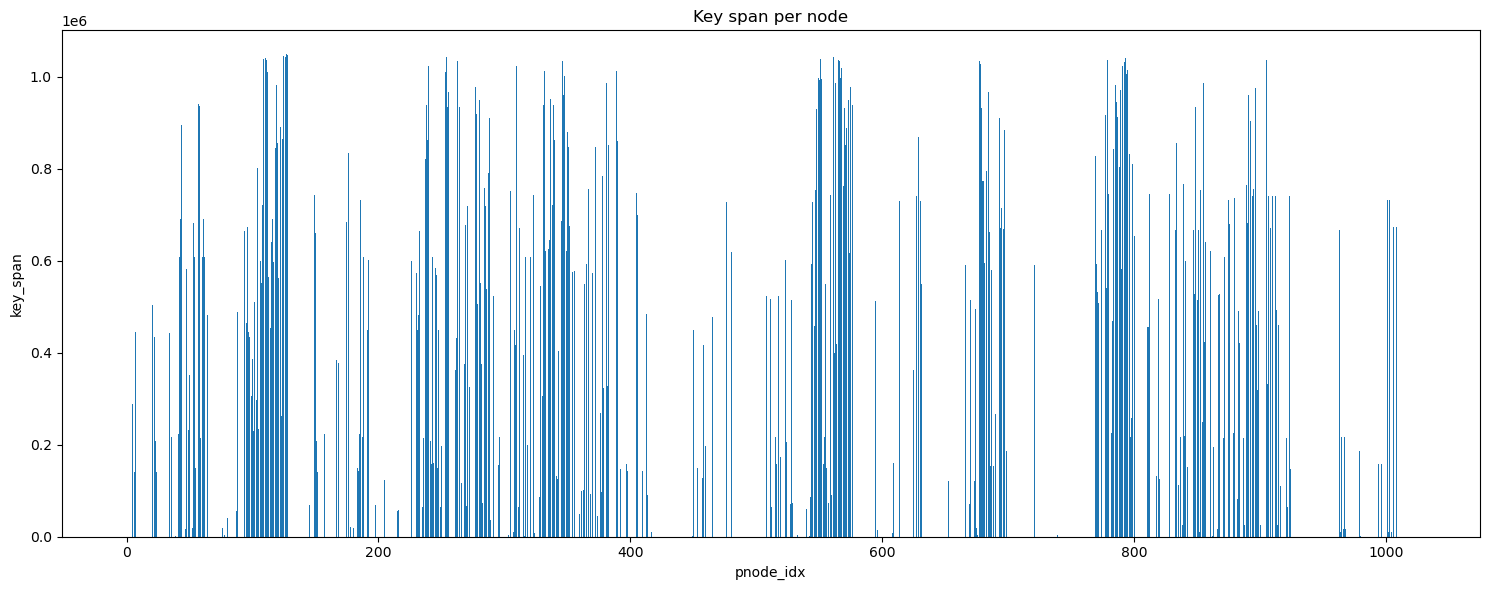

In [12]:
# --- 图2：每个 node 的 key_span（max_key - min_key）---
plt.figure(figsize=(15, 6))
plt.bar(df["pnode_idx"].fillna(0).astype(int), df["key_span"].fillna(0).astype(int))
plt.xlabel("pnode_idx")
plt.ylabel("key_span")
plt.title("Key span per node")
plt.tight_layout()
plt.show()

### About nodes_dump.csv
This file lists all trajectory points stored on each node.

- **pnode_idx**: Index of the node where the record is stored.  
- **node_id**: Identifier of the node on the DHT ring.  
- **key**: Encoded SFC key of the point.  
- **user**: User ID to which the trajectory belongs.  
- **traj_id**: Identifier of the trajectory sequence.  
- **lat**: Latitude of the trajectory point.  
- **lon**: Longitude of the trajectory point.  
- **datetime**: Timestamp of the trajectory point (ISO-8601 format).


In [4]:
csv_path = Path(RUN_DIR) / "node_dump.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"nodes_dump.csv not found at: {csv_path}")

# 读取数据
df = pd.read_csv(
    csv_path,
    dtype={"pnode_idx": "Int64", "node_id": "Int64", "key": "Int64", "user": "Int64", "traj_id": "Int64"},
    parse_dates=["datetime"]
)

print("Rows:", len(df))
df.head(10)

Rows: 19632236


,pnode_idx,node_id,key,user,traj_id,lat,lon,datetime
0,5,5242880,4941349,21,-4971020989573314408,39.101050,115.727933,2007-04-29 15:32:17+00:00
1,5,5242880,4941573,21,-4971020989573314408,39.103983,115.729233,2007-04-29 15:32:09+00:00
2,5,5242880,4943409,21,-4971020989573314408,39.114500,115.735967,2007-04-29 15:31:34+00:00
3,5,5242880,5021768,10,-4615239167271405175,39.000208,115.612657,2007-10-21 20:07:00+00:00
4,5,5242880,5021770,10,-4615239167271405175,39.000673,115.613095,2007-10-21 20:07:02+00:00
5,5,5242880,5021770,10,-4615239167271405175,39.000907,115.613315,2007-10-21 20:07:03+00:00
6,5,5242880,5021770,10,-4615239167271405175,39.001140,115.613535,2007-10-21 20:07:04+00:00
7,5,5242880,5021770,10,-4615239167271405175,39.001605,115.613973,2007-10-21 20:07:06+00:00
8,5,5242880,5021770,10,-4615239167271405175,39.001838,115.614193,2007-10-21 20:07:07+00:00
9,5,5242880,5021774,10,-4615239167271405175,39.002307,115.614633,2007-10-21 20:07:09+00:00


#### Figure 1: Trajectory points (scatter plot)
This scatter plot shows the geographic distribution of all trajectory points stored in the selected node dump.  
- **X-axis:** Longitude  
- **Y-axis:** Latitude  
The figure helps to visualize the spatial footprint of the stored data and check whether the points correspond to realistic trajectories.


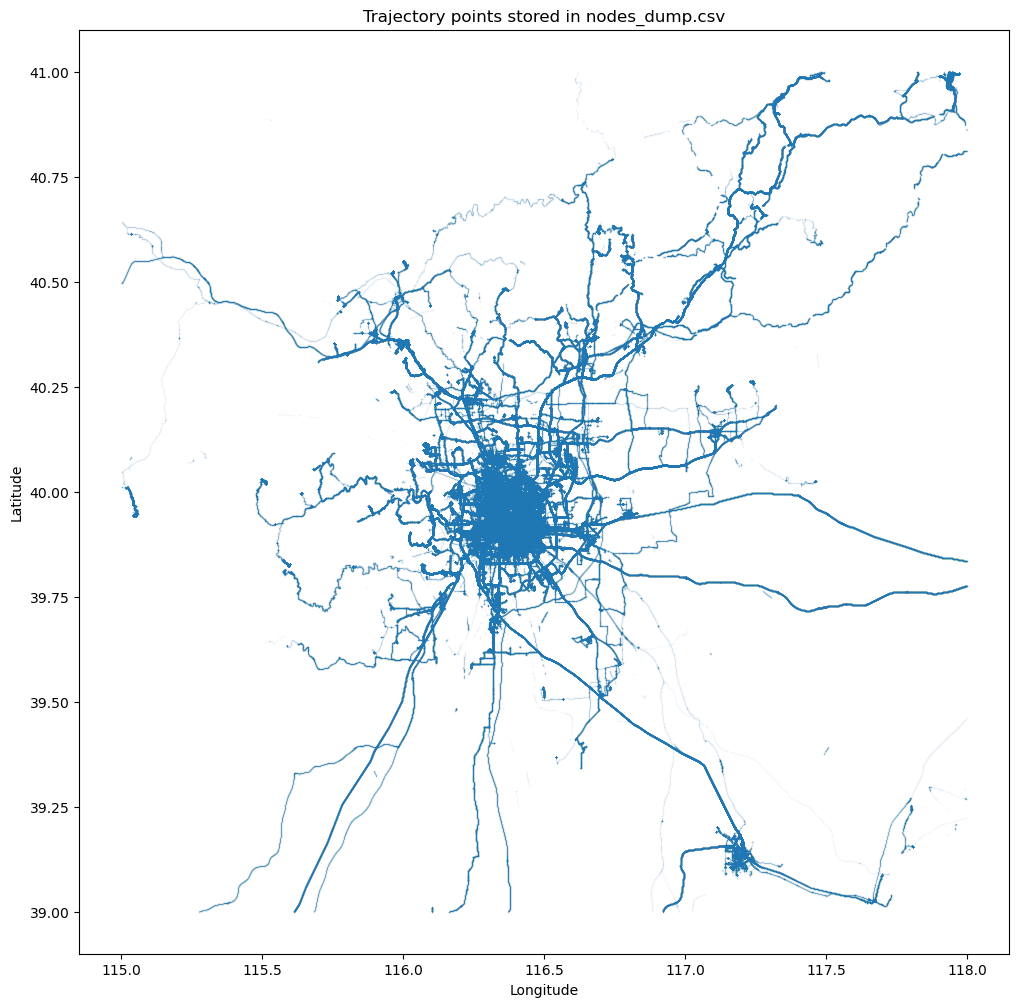

In [8]:
plt.figure(figsize=(12,12))
plt.scatter(df["lon"], df["lat"], s=1, alpha=0.05,linewidth=0)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Trajectory points stored in nodes_dump.csv")
plt.show()

#### Figure 2: Trajectory timeline
This plot shows how latitude and longitude values evolve over time.  
- **X-axis:** Timestamp (`datetime`)  
- **Y-axis:** Latitude and Longitude values  
The figure helps to inspect the temporal continuity of trajectories and identify gaps or irregular sampling intervals.


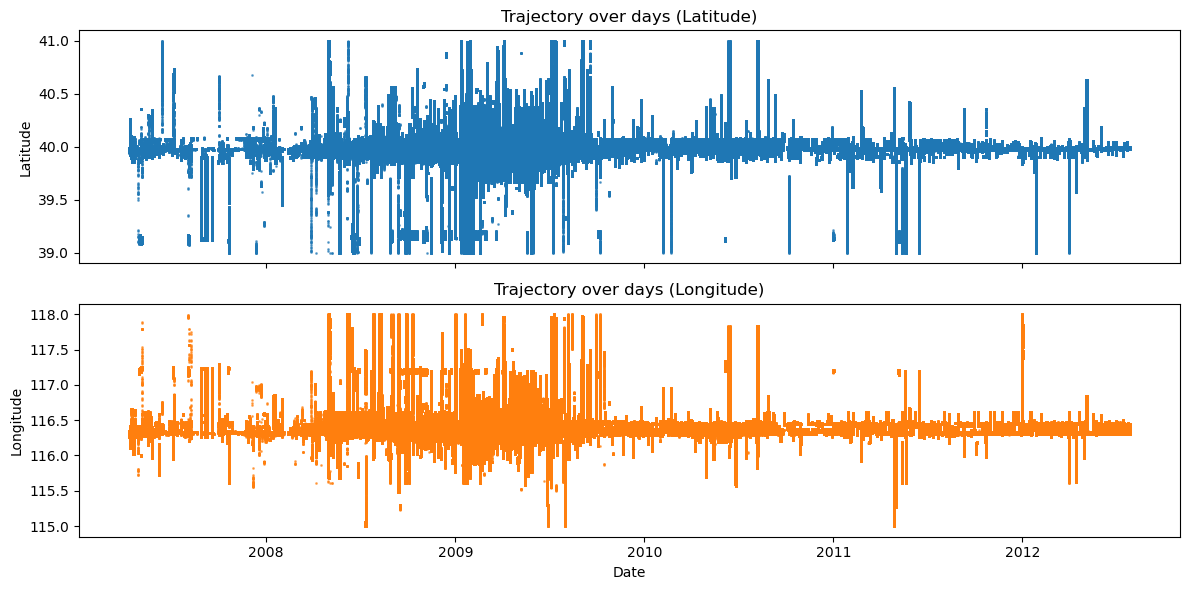

In [9]:
df["date"] = df["datetime"].dt.date  # 只取年月日

fig, axs = plt.subplots(2, 1, figsize=(12,6), sharex=True)

axs[0].plot(df["date"], df["lat"], ".", markersize=2, alpha=0.6, color="tab:blue")
axs[0].set_ylabel("Latitude")
axs[0].set_title("Trajectory over days (Latitude)")

axs[1].plot(df["date"], df["lon"], ".", markersize=2, alpha=0.6, color="tab:orange")
axs[1].set_ylabel("Longitude")
axs[1].set_xlabel("Date")
axs[1].set_title("Trajectory over days (Longitude)")

plt.tight_layout()
plt.show()

#### Figure 3: Points per user
This bar chart shows the number of trajectory points stored for each user ID.  
- **X-axis:** User identifier (`user`)  
- **Y-axis:** Count of trajectory points  
The figure highlights how data is distributed across users, revealing whether some users dominate the dataset.


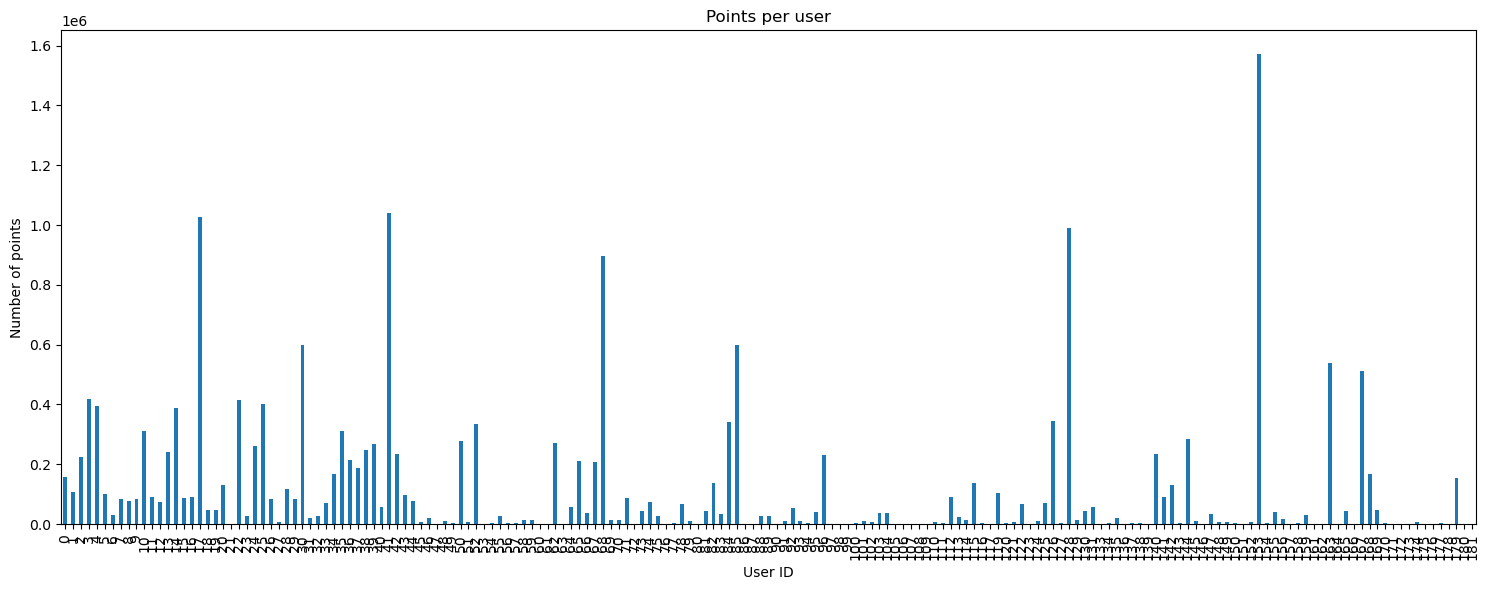

In [10]:
if "user" in df.columns:
    counts = df.groupby("user").size()
    counts.plot(kind="bar", figsize=(15,6))
    plt.xlabel("User ID")
    plt.ylabel("Number of points")
    plt.title("Points per user")
    plt.tight_layout()
    plt.show()

### About node_ranges.csv
This file describes each node's responsibility interval on the key ring and the data actually stored within that interval.

- **pnode_idx**: Index of the node in the experiment (0-based).
- **node_id**: Identifier of the node on the DHT ring.
- **resp_start**: Start of the responsibility interval on the ring (in key space).
- **resp_end**: End of the responsibility interval on the ring (in key space).
- **wrapped**: Whether the interval wraps around the zero point of the ring (if `true`, the interval is split across the end and the beginning of the ring).
- **stored_total**: Number of records actually stored on this node.
- **stored_min**: Minimum key of stored records on this node (if any).
- **stored_max**: Maximum key of stored records on this node (if any).



In [15]:
csv_path = Path(RUN_DIR) / "node_ranges.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"node_ranges.csv not found at: {csv_path}")

df = pd.read_csv(
    csv_path,
    dtype={
        "pnode_idx": "Int64",
        "node_id": "Int64",
        "resp_start": "Int64",
        "resp_end": "Int64",
        "stored_total": "Int64",
        "stored_min": "Int64",
        "stored_max": "Int64",
    },
    na_values=["", " ", "NA", "NaN"]
)

# 规范 wrapped 布尔列
if "wrapped" in df.columns:
    df["wrapped"] = df["wrapped"].astype(str).str.lower().map({"true": True, "false": False})
else:
    df["wrapped"] = False

# ---- 解析 ring_m（来自 params.txt），计算环长 ----
params_path = Path(RUN_DIR) / "params.txt"
if not params_path.exists():
    raise FileNotFoundError(f"params.txt not found at: {params_path} (needed to parse ring_m)")

params_text = params_path.read_text(encoding="utf-8", errors="ignore")
m = re.search(r"ring_m\s*=\s*(\d+)", params_text)
if not m:
    raise ValueError("Unable to parse ring_m from params.txt (expected like 'ring_m=39').")
ring_m = int(m.group(1))
ring_size = 1 << ring_m

print(f"ring_m = {ring_m}, ring_size = {ring_size}")

# ---- 计算责任跨度（模环长）----
# exclusive 跨度： (end - start) mod ring_size
resp_span_excl = (df["resp_end"].astype("Int64") - df["resp_start"].astype("Int64")) % ring_size
df["resp_span"] = resp_span_excl.astype("Int64")
# 也可以给出 inclusive 的跨度（+1），但作图用 resp_span 更直观
df["resp_span_inclusive"] = (df["resp_span"] + 1).astype("Int64")

# 存储区间跨度（若存在）
df["stored_span"] = (df["stored_max"] - df["stored_min"]).astype("Int64")
df["stored_span"] = df["stored_span"].fillna(0)

# 排序（按 pnode_idx）
df = df.sort_values("pnode_idx").reset_index(drop=True)
df.head()

ring_m = 30, ring_size = 1073741824


,pnode_idx,node_id,resp_start,resp_end,wrapped,stored_total,stored_min,stored_max,resp_span,resp_span_inclusive,stored_span
0,0,0,1072693249,0,True,0,<NA>,<NA>,1048575,1048576,0
1,1,1048576,1,1048576,False,0,<NA>,<NA>,1048575,1048576,0
2,2,2097152,1048577,2097152,False,0,<NA>,<NA>,1048575,1048576,0
3,3,3145728,2097153,3145728,False,0,<NA>,<NA>,1048575,1048576,0
4,4,4194304,3145729,4194304,False,0,<NA>,<NA>,1048575,1048576,0


#### Figure 1: stored span per pnode
This bar chart shows the size of each pnode's stored interval on the ring, computed as `(stored_end - stored_start) mod ring_size`.
- **X-axis:** Node index (`pnode_idx`)
- **Y-axis:** stored span (in key counts)
If some nodes cover much larger spans than others, the ring partitioning may be uneven, which can affect routing and load balance.


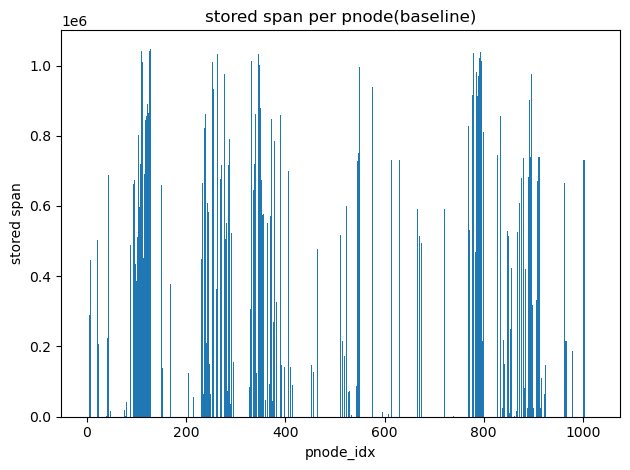

In [19]:
plt.figure()
plt.bar(df["pnode_idx"].astype(int), df["stored_span"].astype("Int64").fillna(0).astype(int))
plt.xlabel("pnode_idx")
plt.ylabel("stored span")
plt.title("stored span per pnode(baseline)")
plt.tight_layout()
plt.show()

### Original data file

In [ ]:
CSV_PATH = 'D:\implementation\p2psta\implementation\geolife_clean.csv' 
# ===== 1. 读数据 =====
df = pd.read_csv(
    CSV_PATH,
    parse_dates=['datetime'],
    dtype={'user': 'category'}
)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:1: SyntaxWarning: invalid escape sequence '\i'
C:\Users\yezhan\AppData\Local\Temp\ipykernel_3832\1541564178.py:1: SyntaxWarning: invalid escape sequence '\i'
  CSV_PATH = 'D:\implementation\p2psta\implementation\geolife_clean.csv'


,user,traj_id,lat,lon,datetime
0,000,000/20081023025304,39.984702,116.318417,2008-10-22 18:53:04+00:00
1,000,000/20081023025304,39.984683,116.318450,2008-10-22 18:53:10+00:00
2,000,000/20081023025304,39.984686,116.318417,2008-10-22 18:53:15+00:00
3,000,000/20081023025304,39.984688,116.318385,2008-10-22 18:53:20+00:00
4,000,000/20081023025304,39.984655,116.318263,2008-10-22 18:53:25+00:00


In [3]:
#统计轨迹点数
num_points = len(df)
print(f"Total trajectory points: {num_points}")

Total trajectory points: 19632236


In [4]:
#统计用户数
num_users = df['user'].nunique()
print(f"Total unique users: {num_users}")

Total unique users: 179


In [5]:
#统计轨迹id数量
num_traj_ids = df['traj_id'].nunique()
print(f"Number of unique traj_id: {num_traj_ids}")

Number of unique traj_id: 17314


In [22]:
t_min, t_max = df.datetime.min(), df.datetime.max()
lat_min, lat_max = df.lat.min(), df.lat.max()
lon_min, lon_max = df.lon.min(), df.lon.max()

print(f'row : {len(df):,}')
print(f'Total days        : {(t_max - t_min).days + 1} days')
print(f'Time span      : {t_min}  ——  {t_max}')
print(f'Latitude range      : {lat_min:.6f}  –  {lat_max:.6f}')
print(f'Longitude range     : {lon_min:.6f}  –  {lon_max:.6f}')

row : 19,632,236
Total days        : 1933 days
Time span      : 2007-04-12 01:31:32+00:00  ——  2012-07-27 00:31:20+00:00
Latitude range      : 39.000000  –  40.999996
Longitude range     : 115.000173  –  117.999978


#### Time distribution of data

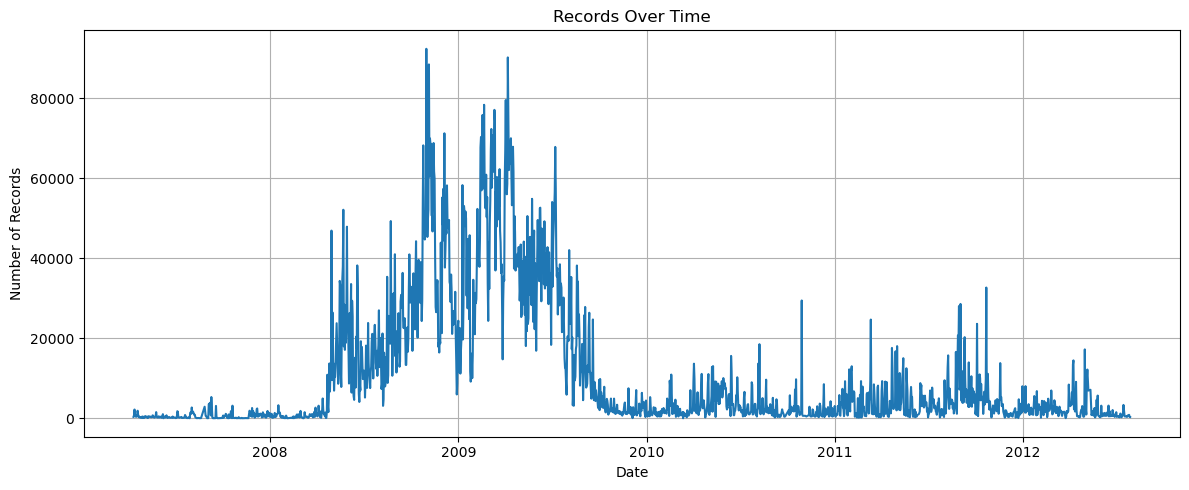

In [17]:
df['date'] = df['datetime'].dt.date
date_counts = df['date'].value_counts().sort_index()
plt.figure(figsize=(12, 5))
plt.plot(date_counts.index, date_counts.values, linestyle='-')
plt.xlabel('Date')
plt.ylabel('Number of Records')
plt.title('Records Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Spatial distribution of data

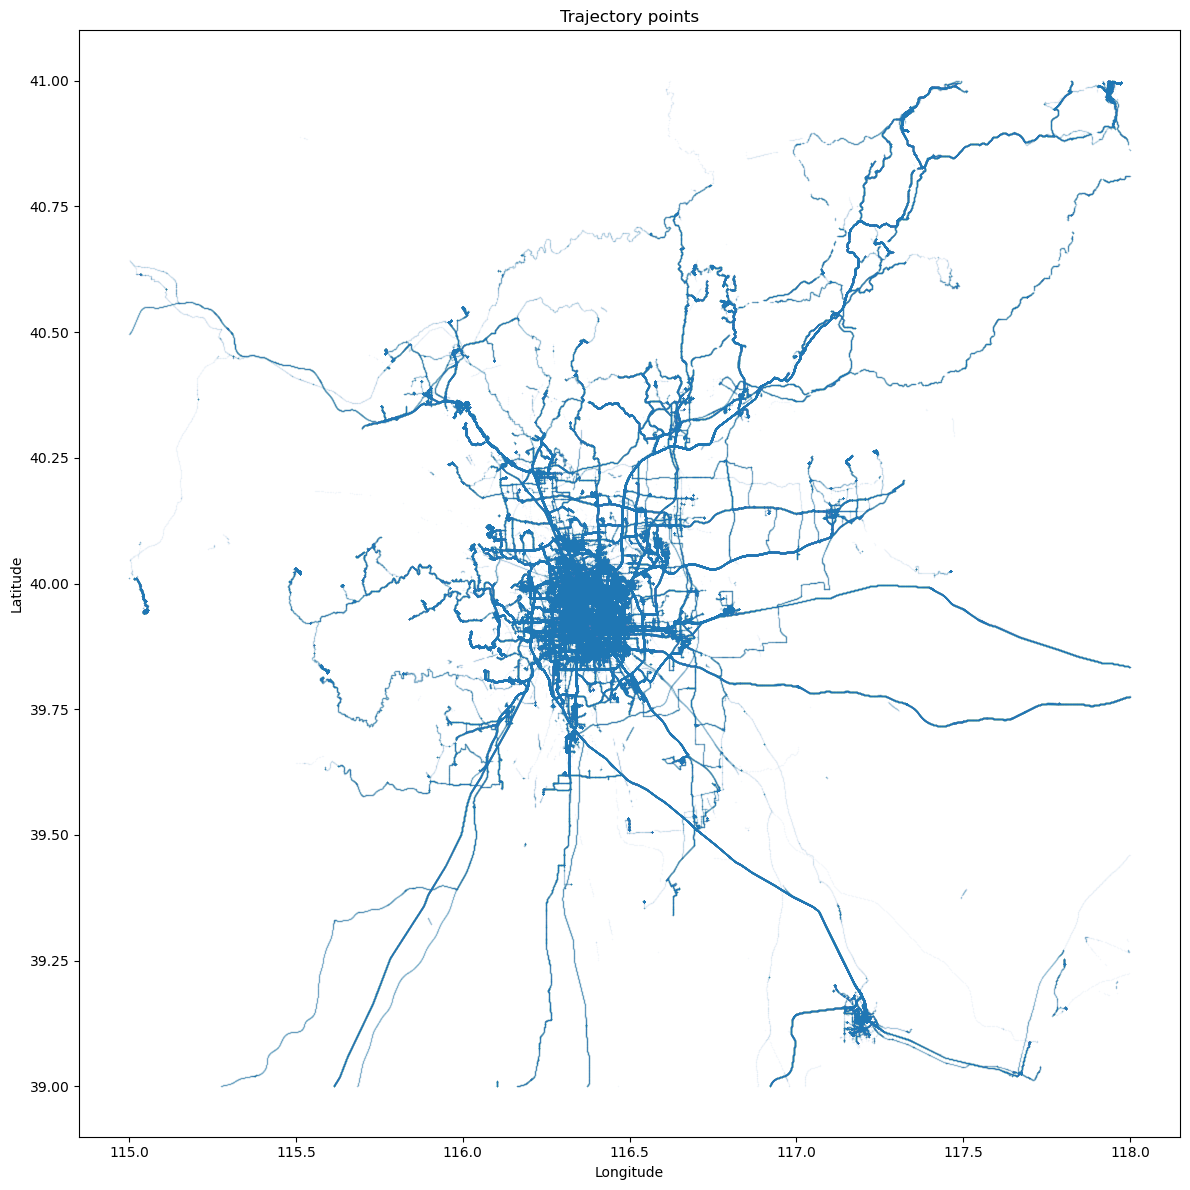

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

plt.figure(figsize=(12,12))
plt.scatter(df["lon"], df["lat"], s=1, alpha=0.05, linewidth=0)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Trajectory points / SFC grid")

ax = plt.gca()
# 主刻度网格
ax.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.8)
# 开启次刻度
ax.xaxis.set_minor_locator(AutoMinorLocator(n=5))  # 每个主刻度间再分5格
ax.yaxis.set_minor_locator(AutoMinorLocator(n=5))
# 次刻度网格（更细密）
ax.grid(True, which="minor", linestyle=":", linewidth=0.6, alpha=0.6)

# 地理散点通常等比例更直观（可选）
#ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()


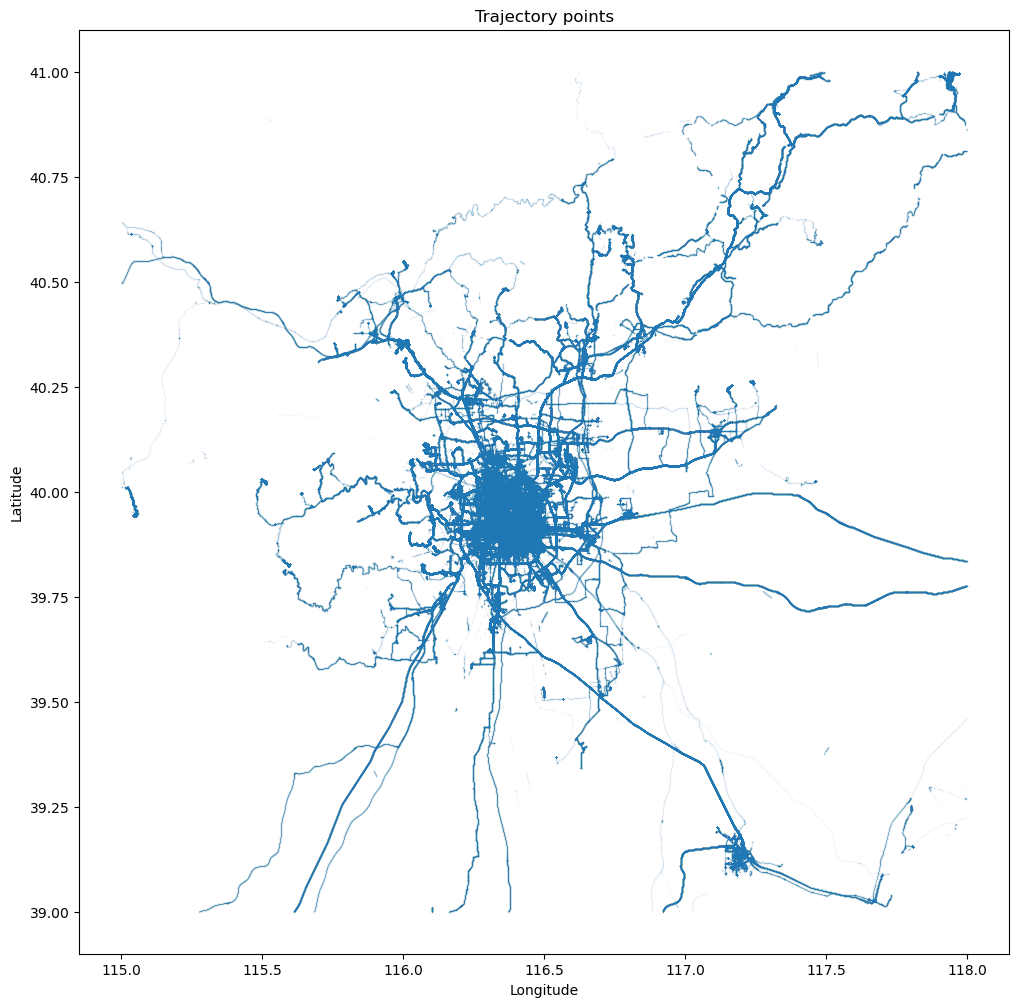

In [8]:
plt.figure(figsize=(12,12))
plt.scatter(df["lon"], df["lat"], s=1, alpha=0.05,linewidth=0)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Trajectory points")
plt.show()

#### The actual data within the query range in the original dataset

In [23]:
QUERIES = {
    'forbidden_city': {
        'lat_min': 39.906, 'lat_max': 39.923,
        'lon_min': 116.386, 'lon_max': 116.411,
        't_start': pd.Timestamp('2008-08-01 03:00:00', tz='UTC'),
        't_end': pd.Timestamp('2008-08-10 03:15:00', tz='UTC')
    },
    'Guomao_CBD': {
        'lat_min': 39.906, 'lat_max': 39.923,
        'lon_min': 116.440, 'lon_max': 116.480,
        't_start': pd.Timestamp('2008-08-01 03:00:00', tz='UTC'),
        't_end': pd.Timestamp('2008-08-10 03:15:00', tz='UTC')
    },
    'Changping_District': {
        'lat_min': 40.080, 'lat_max': 40.150,
        'lon_min': 116.220, 'lon_max': 116.300,
        't_start': pd.Timestamp('2008-08-01 03:00:00', tz='UTC'),
        't_end': pd.Timestamp('2008-08-10 03:15:00', tz='UTC')
    }
}

def summarize(df, queries):
    """return dict：{query_name: {rows, users, trajs, first, last}}"""
    summary = {}
    for name, q in queries.items():
        mask = (
            (df.lat >= q['lat_min']) & (df.lat <= q['lat_max']) &
            (df.lon >= q['lon_min']) & (df.lon <= q['lon_max']) &
            (df.datetime >= q['t_start']) & (df.datetime <= q['t_end'])
        )
        sub = df[mask]
        summary[name] = {
            'rows': int(mask.sum()),
            'users': sub['user'].nunique(),
            'trajs': sub['traj_id'].nunique(),
            'first': sub['datetime'].min(),
            'last': sub['datetime'].max()
        }
    return summary

summary = summarize(df, QUERIES)
for name, s in summary.items():
    print(f"\n=== {name} ===")
    print(f"rows : {s['rows']}")
    print(f"users: {s['users']}")
    print(f"trajs: {s['trajs']}")
    print(f"time : {s['first']}  ~  {s['last']}")

# 顺便打印全表指标
print('\n=== full file ===')
print(f'total rows : {len(df)}')
print(f'total users: {df["user"].nunique()}')
print(f'total trajs: {df["traj_id"].nunique()}')
print(f'time range : {df["datetime"].min()}  ~  {df["datetime"].max()}')


=== forbidden_city ===
rows : 62
users: 1
trajs: 1
time : 2008-08-03 20:49:28+00:00  ~  2008-08-04 07:55:16+00:00

=== Guomao_CBD ===
rows : 1454
users: 2
trajs: 7
time : 2008-08-01 20:02:13+00:00  ~  2008-08-06 19:03:12+00:00

=== Changping_District ===
rows : 344
users: 1
trajs: 3
time : 2008-08-01 03:30:37+00:00  ~  2008-08-08 14:40:20+00:00

=== full file ===
total rows : 19632236
total users: 179
total trajs: 17314
time range : 2007-04-12 01:31:32+00:00  ~  2012-07-27 00:31:20+00:00


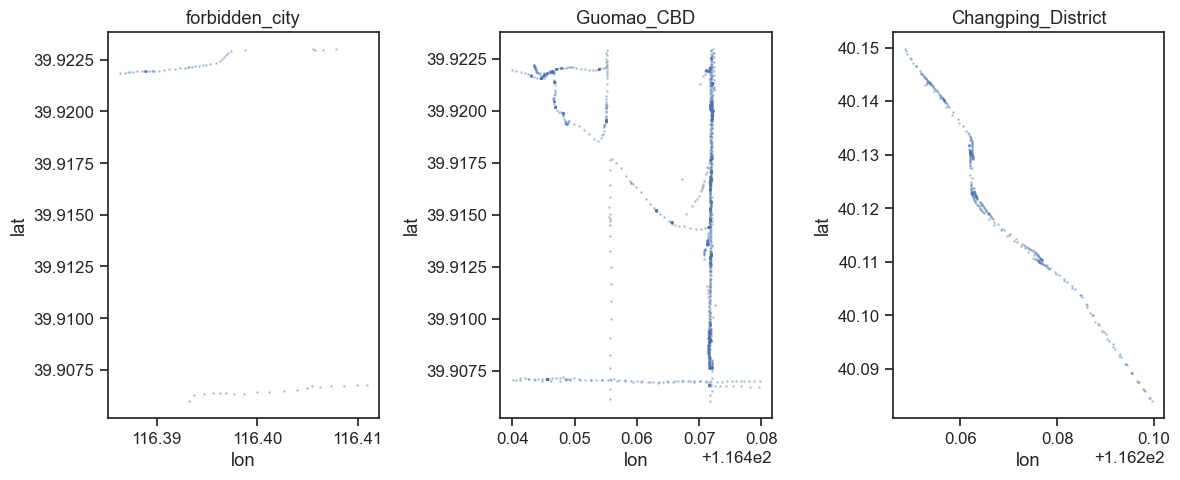

In [26]:
sns.set(style="ticks", font_scale=1.1)
n_query = len(QUERIES)
fig, axes = plt.subplots(1, n_query, figsize=(12, 5))

for ax, (name, q) in zip(axes, QUERIES.items()):
    # 1. 先过滤
    mask = (
        (df.lat >= q['lat_min']) & (df.lat <= q['lat_max']) &
        (df.lon >= q['lon_min']) & (df.lon <= q['lon_max']) &
        (df.datetime >= q['t_start']) & (df.datetime <= q['t_end'])
    )
    sub = df[mask]                  
    if sub.empty:                        
        print(f'{name} no data in range, skipping plot.')
        continue
    # 4. 再抽样
    sub = sub.sample(n=min(5000, len(sub)), random_state=42)
    ax.scatter(sub.lon, sub.lat, s=1, alpha=0.3)
    ax.set_title(name)
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')

plt.tight_layout()
plt.show()

### Query results of project

In [39]:
queries = {
    "forbidden_city": Path(RUN_DIR) / "query_00_forbidden_city",
    "Guomao_CBD":         Path(RUN_DIR) / "query_01_Guomao_CBD",
    'Changping_District': Path(RUN_DIR) / "query_02_Changping_District",
}

files = {
    name: qdir / "query_results.csv"
    for name, qdir in queries.items()
}

dfs = {}
for name, path in files.items():
    df = pd.read_csv(
        path,
        parse_dates=['datetime'],
        dtype={'traj_id': str}
    )
    df['traj_id'] = df['traj_id'].str.strip()

    dfs[name] = df
    
summary = {}
for name, df in dfs.items():
    summary[name] = {
        'rows': len(df),
        'users': df['user'].nunique(),
        'trajs': df['traj_id'].nunique(),
        'first': df['datetime'].min(),
        'last': df['datetime'].max()
    }

for name, s in summary.items():
    print(f'\n=== {name} ===')
    print(f"rows : {s['rows']}")
    print(f"users: {s['users']}")
    print(f"trajs: {s['trajs']}")
    print(f"time : {s['first']}  ~  {s['last']}")


=== forbidden_city ===
rows : 62
users: 1
trajs: 1
time : 2008-08-03 20:49:28+00:00  ~  2008-08-04 07:55:16+00:00

=== Guomao_CBD ===
rows : 1454
users: 2
trajs: 7
time : 2008-08-01 20:02:13+00:00  ~  2008-08-06 19:03:12+00:00

=== Changping_District ===
rows : 344
users: 1
trajs: 3
time : 2008-08-01 03:30:37+00:00  ~  2008-08-08 14:40:20+00:00


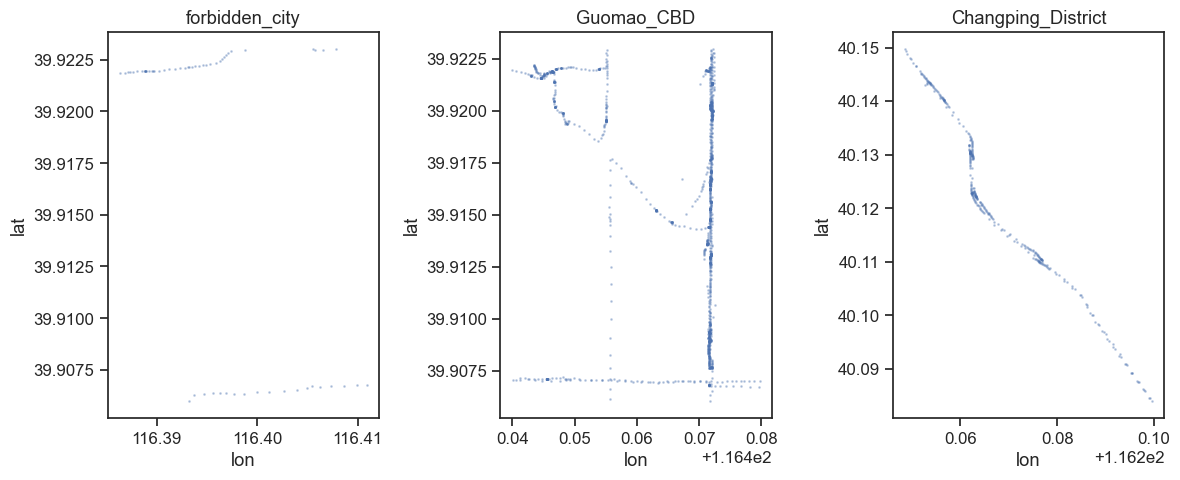

In [40]:
n_query = len(queries)
fig, axes = plt.subplots(1, n_query, figsize=(12, 5))

for ax, (name, df) in zip(axes, dfs.items()):
    if df.empty:
        ax.set_title(f'{name} no data')
        continue
    plot_df = df.sample(n=min(5000, len(df)), random_state=42)
    ax.scatter(plot_df.lon, plot_df.lat, s=1, alpha=0.3)
    ax.set_title(name)
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')

plt.tight_layout()
plt.show()

In [41]:

queries = {
    "forbidden_city": Path(RUN_DIR) / "query_00_forbidden_city",
    "Guomao_CBD":         Path(RUN_DIR) / "query_01_Guomao_CBD",
    'Changping_District': Path(RUN_DIR) / "query_02_Changping_District",
}
MAX_PREVIEW_LINES = 60  # 预览显示的行数，可按需调整

def read_text_file(path: Path) -> str:
    if not path.exists():
        return f"[MISSING] {path}"
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
        try:
            return path.read_text(encoding=enc, errors="replace")
        except Exception:
            continue
    return f"[ERROR] Failed to read {path}"

def show_collapsible(title: str, text: str, max_preview_lines: int = 60):
    lines = text.splitlines()
    preview = "\n".join(lines[:max_preview_lines])
    more = max(0, len(lines) - max_preview_lines)

    esc_title = html.escape(title)
    esc_preview = html.escape(preview)
    esc_full = html.escape(text)

    html_block = f"""
    <div style='margin:0.75rem 0;'>
      <div style='font-weight:700; margin-bottom:4px;'>{esc_title}</div>
      <div style='border:1px solid #ddd; border-radius:6px; padding:8px;'>
        <div style='max-height:280px; overflow:auto; white-space:pre; font-family:monospace;'>{esc_preview}</div>
        {'<div style="color:#888; font-style:italic; margin-top:4px;">… ' + str(more) + ' more lines</div>' if more>0 else ''}
        <details style='margin-top:6px;'>
          <summary>Show full</summary>
          <div style='max-height:420px; overflow:auto; white-space:pre; font-family:monospace; margin-top:6px;'>{esc_full}</div>
        </details>
      </div>
    </div>
    """
    display(HTML(html_block))

for name, qdir in queries.items():
    display(HTML(f"<h3 style='margin-top:1.25rem'>QUERY: {html.escape(name)}</h3>"))

    win_path = qdir / "window.txt"
    sum_path = qdir / "summary.txt"

    win_txt = read_text_file(win_path)
    sum_txt = read_text_file(sum_path)

    show_collapsible(f"window.txt — {win_path}", win_txt, MAX_PREVIEW_LINES)
    show_collapsible(f"summary.txt — {sum_path}", sum_txt, MAX_PREVIEW_LINES)


In [42]:
queries = {
    "forbidden_city": Path(RUN_DIR) / "query_00_forbidden_city",
    "Guomao_CBD":         Path(RUN_DIR) / "query_01_Guomao_CBD",
    'Changping_District': Path(RUN_DIR) / "query_02_Changping_District",
}
files = {name: qdir / "pnode_report.csv" for name, qdir in queries.items()}

dfs = {}
for name, path in files.items():
    df = pd.read_csv(
        path
    )
    dfs[name] = df
    
summary = {}
for name, df in dfs.items():
    summary[name] = {
        'total_pnodes': df['pnode_idx'].nunique(),
        'total_count': df['returned_count'].sum(),
        'total_hops': df['route_hops'].sum(),
    }

for name, s in summary.items():
    print(f'\n=== {name} ===')
    print(f"total pnodes: {s['total_pnodes']}")
    print(f"total count : {s['total_count']}")
    print(f"total hops  : {s['total_hops']}")
    print(f"avg hops/pnode: {s['total_hops'] / s['total_pnodes'] if s['total_pnodes'] > 0 else 0:.4f}")
    print(f"avg count/pnode: {s['total_count'] / s['total_pnodes'] if s['total_pnodes'] > 0 else 0:.4f}")
    print(f"avg count/hop : {s['total_count'] / s['total_hops'] if s['total_hops'] > 0 else 0:.4f}")    



=== forbidden_city ===
total pnodes: 2
total count : 62
total hops  : 14
avg hops/pnode: 7.0000
avg count/pnode: 31.0000
avg count/hop : 4.4286

=== Guomao_CBD ===
total pnodes: 2
total count : 1454
total hops  : 14
avg hops/pnode: 7.0000
avg count/pnode: 727.0000
avg count/hop : 103.8571

=== Changping_District ===
total pnodes: 4
total count : 344
total hops  : 22
avg hops/pnode: 5.5000
avg count/pnode: 86.0000
avg count/hop : 15.6364
